# Tutorial: Physics Informed Neural Networks (PINN)
> For the Fall 2024 course: *Machine Learning in Physics*<br>
> Created: Aug. 14, 2024 Harrison B. Prosper<br>
> Updated: Oct. 06, 2025 HBP

## Introduction
Most differential equations cannot be solved exactly. Therefore, over the centuries numerical methods have been devised to solve these equations approximately. A relatively recent numerical approach called **physics-informed neural networks** (PINN) formulates the solution of a differential equation as an optimization problem in which the approximate solution is modeled using one or more neural networks. For an excellent introduction, I recommend the lectures by Bob Moseley[1]. For a thorough review, see Ref.[2]. The approach is feasible thanks to **automatic differentiation**, which enables the derivatives that enter the objective function (that is, empirical risk, average loss, or cost) to be computed *exactly*.

The term physics-informed neural network is clearly a misnomer because the method can be applied to *any* differential equation, not only the ones in physics! 

In this tutorial we consider the example presented by Bob Moseley in the lecture cited above, namely, the solution $x(t) \in \mathbb{R}$, $t \in \mathbb{R}^+$, of the ordinary differential equation (ODE)
\begin{align}
   \frac{d^2 x}{dt^2} + 2 \lambda \frac{d x}{ dt } + \omega_0^2 x = 0,
\end{align}
describing a 1D **damped harmomic oscillator**, where 
\begin{align}
    \lambda & = \frac{c}{m} \quad\text{and}\\
    \omega_0 & = \sqrt{\frac{k}{m}}
\end{align}
are the characteristic decay rate of the oscillation amplitude and the characteristic angular frequency, respectively. (We follow the notation in Ref.[3], but note that in Bob Moseley's lecture $\lambda \equiv \delta$ and $x(t) \equiv u(t)$.) The quantity $m$ is the mass of the oscillating object, $k$ is the spring constant and $c$ is the *viscous damping coefficient*[3].  

## Exact Solution
It is almost always a good idea to try to simplify a differential equation before solving it. We can simplify the ODE by dividing throughout by $\omega_0^2$ and defining the dimensionless quantities $z = \omega_0 \, t$ and $\zeta = \lambda /\omega_0 $; $\zeta$ is called the *damping ratio* and is proportional to the ratio of the natural oscillation and damping timescales. With these changes the ODE becomes
\begin{align}
  \frac{d^2 x}{d z^2}  +  2 \zeta \frac{d x}{dz} + x = 0 ,
\end{align}
which shows that the damped harmonic oscillator is governed by the single parameter $\zeta$. To obtain a particular solution of the equation we must specify initial conditions
\begin{align}
    x(0) & = x_0, \\
    \left. \frac{d x}{dz} \right|_{z=0} & = v_0 . 
\end{align}
Since this is a linear equation, let's try a solution of the form 
\begin{align}
    x(z) & = A \exp(i q z + \phi),
\end{align}
where $A$ and $\phi$ are constants to be determined by the initial conditions and where it is understood that we'll take the real part of $x(z)$ at the end. One finds $q = i \zeta \pm \sqrt{1 - \zeta^2}$, that is, 
\begin{align}
    x(z) 
         & = A \exp(-\zeta z) \exp(\pm i z \sqrt{1 - \zeta^2} + \phi).
\end{align}

Taking the positive value of $\sqrt{1 - \zeta^2}$ and restricting to the (underdamped) condition $\zeta < 1$ the exact solution is given by
\begin{align}
    x(z) & = A \exp(-\zeta z) \, \cos\left(z \sqrt{1-\zeta^2} + \phi\right)  \quad\text{and} \\
   A & = \frac{x_0}{\cos\phi} , \quad  \phi = \arctan\left[-\frac{(\zeta + v_0 / x_0)}{\sqrt{1 - \zeta^2}}\right].
\end{align}
In terms of the original parameters, 
 the exact solution of the ODE for $\zeta < 1$, that is, $\omega_0 > \lambda$, is 
\begin{align}
    x(t) & = A \exp(-\lambda t) \, \cos(\omega \, t + \phi), \quad\text{with } \omega = \sqrt{\omega_0^2 - \lambda^2} \quad\text{and} \\
     A & = x_0 \, / \, \cos\phi , \quad \phi = \arctan(-(\lambda + v_0 / x_0) \, / \, \omega),
\end{align}
with $v_0$ now defined to be $v_0 = dx(0) / dt$ rather than $dx(0) / dz$.

## Physics-Informed Neural Networks
Automatic differentiation is the key technology that has enabled the use of increasingly complex models in contemporary machine learning. The same technology can be used to compute derivatives with respect to the inputs of a model. However, when the computation graph over the model parameters is extended to incorporate derivatives of the model output with respect to its inputs, this can lead to an explosion in the size of the graph, which makes solving differential equations through this method considerably slower than algorithms that use finite differences. 

But if we condition the solution on the initial conditions $x_0$ and $v_0$ the high cost of finding the solutions using stochastic gradient descent for a *subset*, $S \subset \mathbb{R}^2$, of initial conditions is *amortized* over the subsequent rapid application of the PINN for any initial condition within $S$. In effect, the PINN approximates an *infinite* set of solutions each indexed by the parameters $(x_0, v_0)$. Furthermore, the physics parameters of the problem, here $\zeta$, can be included in the subset $S$, $(x_0, v_0, \zeta) \in S \subset \mathbb{R}^3$, thereby greatly extending the class of solutions. In a finite-difference approach for solving a differential equation, a different calculation is needed for each set of initial (and/or boundary) conditions and physics parameters. A PINN conditioned on the initial conditions is sometimes called a **conditioned PINN** (CPINN).  One of the nice features of PINNs is that their solutions can be checked explicitly at a few selected parameter points by comparing PINN solutions with solutions obtained using finite-difference methods.

The PINN approach applied to the damped harmonic oscillator entails solving the differential equation by minimizing the following empirical risk (average loss, objective, or cost function)
\begin{align}
    R_\text{ode}(\omega) & = \frac{1}{N_\text{ode}} \sum_{i=1}^{N_\text{ode}} \left(  \frac{d^2f_i}{dz_i^2} + 2 \zeta \frac{df_i}{dz_i} + f_i \right)^2, \quad\quad
    f_i  \equiv f_\omega(z_i) ,
\end{align}
where $\omega$ denotes the parameters of the model $f_\omega(z)$ that approximates the solution $x(z_i)$. 
The $z_i$ are called **collocation points**[1,2]. In the standard PINN approach, additional terms are added to incorporate the initial and, or, boundary conditions and any additional data that constrains the solution. 
In this tutorial, we attempt to solve the equation first using no additional data and with the initial conditions incorporated explicitly [4] using the solution *ansatz*
\begin{align}
    f_\omega(z, p)  &= x_0 + g_\omega(z, p) - g_\omega(0, p) + z \, \left[ v_0 - \dot{g}_\omega(0, p) \right],  \quad p = (x_0, v_0, \zeta),
\end{align}
where an overdot denotes differentiation with respect to $z$. The initial conditions and the physics model parameter $\zeta$, collectively denoted by $p$, will be inputs to the machine learning model thereby producing a *single* ML model that smoothly interpolates solutions for differing values of $p$ within the continuous, compact, domain $$(z, x_0, v_0, \zeta) \in [0, 20] \otimes [-1, 1] \otimes [-2, 2] \otimes [0.0, 1.0] \subset \mathbb{R}^4.$$

## Data average loss
It is sometimes helpful to guide the training by adding a data constraint of the form
\begin{align}
    R_\text{data}(\omega) & = \frac{1}{N_\text{data}} \sum_{i=1}^{N_\text{data}} \left(f_i - x_i \right)^2, \quad\quad
    x_i  \equiv x(z_i) ,
\end{align}
to the average loss, 
where the $x_i$ are known solution points, here, the solution at (dimensionless) time $z_i$. In this tutorial, the solution points are found from the known exact solution. In general, however, the data would be real observational data and, or, points obtained  by solving the ODE using standard numerical methods. Combining the two average loss terms, the overall average loss is gven by 
\begin{align}
    R(\omega) & = (1 - \epsilon) R_\text{ode} + \epsilon \, R_\text{data},\quad 0 \le \epsilon < 1 ,
\end{align}
where $\epsilon$ is a tunable hyperparameter.

### References
  1. B. Moseley, see, for example, https://www.youtube.com/watch?v=IDIv92Z6Qvc; B. Moseley, Deep Learning in Scientific Computing (2023), ETH Zürich, Computational and Applied Mathematics Laboratory (CAMLab).
  2. S. Cuomo et al., *Scientific Machine Learning through Physics-Informed Neural Networks: Where we are and What's next*, https://doi.org/10.48550/arXiv.2201.05624.
  3. https://en.wikipedia.org/wiki/Harmonic_oscillator
  4. D. Mortari, The Theory of Connections: Connecting Points, Mathematics, vol. 5, no. 57, 2017.

## Running on Google Colab
If on Google Colab (https://colab.research.google.com), execute cell below.

In [1]:
try:
    import google.colab
    
    REPO = 'hbprosper/mlinphysics'
    
    url = f"https://raw.githubusercontent.com/{REPO}/refs/heads/main"
    !wget -q {url}/clone2colab.ipynb -O clone2colab.ipynb
    %run clone2colab.ipynb
    
    IN_COLAB = True
    
except ImportError:
    
    IN_COLAB = False

In [2]:
# standard system modules
import os, sys

# standard module for tabular data
import pandas as pd

# standard module for array manipulation
import numpy as np

# standard module for high-quality plots
import matplotlib as mp
import matplotlib.pyplot as plt

# standard research-level machine learning toolkit from Meta (FKA: FaceBook)
import torch
import torch.nn as nn
import torch.nn.init as init

# to reload modules
import importlib

# ML in physics module
import mlinphysics.nn as mlp
import mlinphysics.utils.data as dat
import mlinphysics.utils.monitor as mon

# module for shell utilities
import shutil

plt.rcParams.update({
      "text.usetex": shutil.which('latex') is not None,
      "font.family": "sans-serif",
      "font.sans-serif": "Helvetica",
      "font.size": 14
})

In [3]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\n\tComputational device: {str(DEVICE):4s}\n')


	Computational device: cpu 



## Exact solution for $\zeta < 1$
\begin{align}
    x(z) & = A \exp(-\zeta z) \, \cos\left(z \sqrt{1-\zeta^2} + \phi\right)  \quad\text{and} \\
    A & = \frac{x_0}{\cos\phi}, \quad \phi = \arctan\left[-\frac{(\zeta + v_0 / x_0)}{\sqrt{1 - \zeta^2}}\right] .
\end{align}

In [4]:
def exact_solution(z, x0, v0, zeta):
    assert zeta > 0
    assert zeta < 1
    a = np.sqrt(1 - zeta**2)
    phi = np.arctan(-(zeta + v0/x0)/a)
    A = x0 / np.cos(phi)
    x = A * np.exp(-zeta*z) * np.cos(a*z + phi)
    return torch.tensor(x)

## Configuration

In [5]:
dataset_size_exponent = 17
dataset_size = 2**dataset_size_exponent  # Sobol sample size
test_size    = 2**13                     # test sample size
val_size     = 2**11                     # validation sample size
batch_size   = 2**8

# domain of PINN solution
#                  z,  x0,  v0, zeta
lower_bounds = [ 0.0,-1.0,-2.0,  0.0]
upper_bounds = [20.0, 1.0, 2.0,  1.0]
scale_factor = [20.0, 1.0, 2.0,  1.0] 

# name of model
name = 'pinn'

# choose whether to create or load a configuration file
load_existing_config = False

if load_existing_config:
    config = mlp.Config(f'{name}.yaml')
else:
    # create new configuration
    config = mlp.Config(name, dirname=name)

    # training configuration
    # -----------------------------------------
    train_size = dataset_size - val_size

    config('batch_size', batch_size)
    config('train_size', train_size)           # set training sample size
    config('test_size',  test_size)            # set test sample size
    config('val_size',   val_size)             # set validation sample size

    config('monitor_step',  100)  # set monitor training every "n" iterations
    config('delete', True)        # delete losses file before training, if True
    config('frac', 0.015)         # save model if average loss decreases by more
                                  # than frac percent

    # optimizer / scheduler configuration
    # -----------------------------------------
    # a step comprises a given number of iterations
    config('n_iters_per_step', 150_000)
    config('n_steps', 1)          # number of training steps
    config('n_iterations', config('n_steps') * config('n_iters_per_step'))

    config('base_lr', 5e-4)       # initial learning rate
    config('gamma', 0.50)         # learning rate scale factor

    print(f'\nSave configuration to file {config.cfg_filename}\n')
    config.save()

print(config)


Save configuration to file runs/pinn/pinn_config.yaml

name: pinn
file:
  losses: runs/pinn/pinn_losses.csv
  params: runs/pinn/pinn_params.pth
  init_params: runs/pinn/pinn_init_params.pth
  plots: runs/pinn/pinn_plots.png
batch_size: 256
train_size: 129024
test_size: 8192
val_size: 2048
monitor_step: 100
delete: true
frac: 0.015
n_iters_per_step: 150000
n_steps: 1
n_iterations: 150000
base_lr: 0.0005
gamma: 0.5



## Train, validation, and test sets
There is some confusion in terminology regarding validation and test samples (or sets). We shall adhere to the defintions given here https://machinelearningmastery.com/difference-test-validation-datasets/):
   
  * __Training Dataset__: The sample of data used to fit the model.
  * __Validation Dataset__: The sample of data used to decide 1) whether the fit is reasonable (e.g., the model has not been overfitted), 2) decide which of several models is the best and 3) tune model hyperparameters.
  * __Test Dataset__: The sample of data used to provide an unbiased evaluation of the fitted model.

The validation set will be some small fraction of the training set and will be used to decide when to stop the training.

## Generate raw data
Generate a quasi-random set of points, $p$, in $S_z \otimes S \subset \mathbb{R}^4$, where the set $S_z = [0, 20]$ with $z \in S_z$. Quasi-random sampling disributes points more evenly than uniform random sampling by reducing the degree if random clumping that characterizes random sampling.

In [6]:
sobol_sample = dat.SobolSample(lower_bounds, upper_bounds,
                               num_points_exp=dataset_size_exponent)
print()

uniform_sample = dat.UniformSample(lower_bounds, upper_bounds,
                                   num_points=test_size)

sobol_sample.shape, uniform_sample.shape

SobolSample
  131072 Sobol points created in unit 4-cube.

UniformSample
  8192 uniformly sampled points created in unit 4-cube.


((131072, 4), (8192, 4))

## Package raw data into `Dataset`s

In [7]:
importlib.reload(dat)

train_size = config('train_size')
val_size   = config('val_size')
test_size  = config('test_size')

# training dataset (this defines the empirical risk to be minimized)
print('training data')
train_data = dat.Dataset(sobol_sample,
                         start=0,
                         end=train_size,
                         # split at: y = x[:, split_col:], x = x[:, :split_col]
                         split_col=1,  
                         requires_grad=True)

# a random subset of the training data to check for overtraining
# by comparing with the empirical risk from the validation set
print('training data for validation')
train_data_val = dat.Dataset(sobol_sample,
                             start=0,
                             end=train_size,
                             split_col=1,
                             requires_grad=True,
                             random_sample_size=val_size)


# validation dataset (for monitoring training)
print('validation data')
val_data = dat.Dataset(uniform_sample,
                       start=0,
                       end=val_size, 
                       split_col=1,
                       requires_grad=True)

# test dataset
print('test data')
test_data= dat.Dataset(uniform_sample,
                       start=val_size,
                       end=val_size + test_size,
                       split_col=1,
                       requires_grad=True)

training data
Dataset
  shape of x: torch.Size([129024, 1])
  shape of y: torch.Size([129024, 3])

training data for validation
Dataset
  shape of x: torch.Size([2048, 1])
  shape of y: torch.Size([2048, 3])

validation data
Dataset
  shape of x: torch.Size([2048, 1])
  shape of y: torch.Size([2048, 3])

test data
Dataset
  shape of x: torch.Size([6144, 1])
  shape of y: torch.Size([6144, 3])



## Define `DataLoader`s

In [8]:
print('train data loader')
train_loader = dat.DataLoader(train_data,
                              batch_size=config('batch_size'),
                              num_iterations=config('n_iterations'))

print('train data loader for validation')
train_loader_val = dat.DataLoader(train_data_val,
                                  batch_size=len(train_data_val))

print('validation data loader')
val_loader  = dat.DataLoader(val_data,
                             batch_size=len(val_data))

print('test data loader')
test_loader = dat.DataLoader(test_data,
                             batch_size=len(test_data))

train data loader
DataLoader
  Number of iterations has been specified
  maxiter:          150000
  batch_size:          256
  shuffle_step:        504

train data loader for validation
DataLoader
  maxiter:               1
  batch_size:         2048
  shuffle_step:          1

validation data loader
DataLoader
  maxiter:               1
  batch_size:         2048
  shuffle_step:          1

test data loader
DataLoader
  maxiter:               1
  batch_size:         6144
  shuffle_step:          1



## Define Solution ansatz
We incorporate the initial conditions $x_0, v_0$ explicitly using the following solution ansatz
\begin{align}
    f_\omega(z, p)  &= x_0 + g_\omega(z, p) - g_\omega(0, p) + z \, \left[ v_0 - \dot{g}_\omega(0, p) \right],  \quad p = (x_0, v_0, \zeta),
\end{align}
where $g_\omega(z, p)$ is a neural network with parameters $\omega$ and $z$ and $p = ( x_0, v_0, \zeta)$ are its inputs. 

In [9]:
class Solution(mlp.Model):
    
    def __init__(self, net, scale, use_ToC=False):

        # remember to initialize base (that is, parent) class
        super().__init__()

        # cache neural network and send to computational device
        self.g = net  
        
        # 1. "scale" is needed to ensure that the inputs to the 
        # neural network g(z, p) are of O(1). 
        # 2. unsqueeze(dim=0) does the following to the shape of 
        # the tensor: (3) => (1, 3).
        # 3. use register_buffer to tell PyTorch to save the
        # scale factors, which are used to scale the inputs to
        # the network, along with the network weights, but do 
        # not optimize them!
        self.register_buffer('zscale', torch.tensor(scale[0]).unsqueeze(dim=0))
        self.register_buffer('pscale', torch.tensor(scale[1:]).unsqueeze(dim=0))
        self.register_buffer('use_ToC',torch.tensor(use_ToC).unsqueeze(dim=0))

    def forward(self, z, p):
        """
        if use_ToC, apply the ToC-based ansatz to enforce 
        initial conditions:
          
            f(z, p) = x0 + g(z, p) - g(0, p) + z * [v0 - dot(g)(0, p)]
        else
            f(z, p) = (x0 + z * v0 + z*z * g(z, p)) / (1 + z*z)

        Assumes:
        - z: dimensionless time (omega0 * t) of shape (batch_size, 1) or (1,)
        - p: initial conditions and physics model parameter; shape: (batch_size, 3) or (3,)
        """

        # Handle batched or unbatched initial conditions
        if p.ndim < 2:
            x0 = p[0].view(-1, 1)     # shape: (batch_size, 1)
            v0 = p[1].view(-1, 1)
        else:
            x0 = p[:, 0].view(-1, 1)
            v0 = p[:, 1].view(-1, 1)

        # Scale inputs to network so that they are of O(1)
        z_scaled = z / self.zscale
        p_scaled = p / self.pscale
        gz = self.g(z_scaled, p_scaled)

        if self.use_ToC:
            # Zero input with gradient tracking for computing dg/dz at z=0
            zeros = torch.zeros_like(z, requires_grad=True)
            g0 = self.g(zeros, p_scaled)

            # Compute dg/dz evaluated at z=0
            gdot0 = torch.autograd.grad(
                g0, zeros, 
                grad_outputs=torch.ones_like(g0),
                create_graph=True
            )[0]
            
            # ToC: apply the ansatz to enforce exact boundary constraints
            f = x0 + gz - g0 + z * (v0 - gdot0)
        else:
            # ad hoc ansatz from HBP
            f = (x0 + z * v0 + z*z * gz) / (1 + z*z)

        return f
        
    def diff(self, x, z):
        """
        Computes dx/dz using autograd
        """
        dxdz = torch.autograd.grad(
            x, z, 
            grad_outputs=torch.ones_like(x), 
            create_graph=True
        )[0]
        return dxdz

## Objective function
\begin{align}
    \frac{d^2x}{dz^2} + 2 \zeta \frac{dx}{dz} + x & = 0.
\end{align}

In [10]:
class Objective(mlp.Model):
    """
    Define the physics-based average loss for the PINN.
    Computes the ODE residual: ddot(x) + 2*zeta*dot(x) + x,
    and returns either the mean squared residual or the 
    residuals themselves.
    """
    def __init__(self, solution, return_residuals=False):
        super().__init__()
        self.solution = solution
        self.return_residuals = return_residuals

    def eval(self):
        self.solution.eval()

    def train(self):
        self.solution.train()
    
    def forward(self, z, p):
        # Assumes inputs come with shape (batch_size, D); no need to squeeze.
            
        # Compute x from the solution ansatz
        x = self.solution(z, p)

        # First derivative dx/dz
        #
        # Note: autograd.grad computes the gradient of scalars, but since
        # x(z) is generally a batch of scalars with shape (batch-size, 1), 
        # we need to tell autograd.grad to apply the gradient operator to 
        # every scalar in the batch. We do this by passing autograd.grad a 
        # tensor of shape (batch-size, 1). It is also necessary to create 
        # the computation graph for this operation. Finally, we take the 
        # zeroth element of the returned object because autograd.grad 
        # returns a tuple.
        dxdz = torch.autograd.grad(
            x, z, 
            grad_outputs=torch.ones_like(x),
            create_graph=True
        )[0]

        # Second derivative d^2x/dz^2
        d2xdz2 = torch.autograd.grad(
            dxdz, z, 
            grad_outputs=torch.ones_like(dxdz),
            create_graph=True
        )[0]

        zeta = p[:, -1].view(-1, 1)
        
        # Residuals of the ODE
        F = d2xdz2 + 2 * zeta * dxdz + x
        R_ode = torch.mean(F**2)
        
        return R_ode

## Instantiate training objects
  1. gnet: $g_\omega(z, p)$
  2. solution: $f_\omega(z, p)$
  3. objective
  4. optimizer
  5. scheduler
  6. monitor

In [11]:
gnet      = mlp.FCNN(n_inputs=4, n_hidden=4, n_width=32).to(DEVICE)
gnet.apply(mlp.initialize_parameters) # initialize parameters

solution  = Solution(gnet, scale_factor).to(DEVICE)

objective = Objective(solution).to(DEVICE)

optimizer = torch.optim.Adam(solution.parameters(), lr=config('base_lr'))

# instantiate learning rate step scheduler
scheduler = mlp.LRStepScheduler(
    optimizer,  
    n_steps=config('n_steps'), 
    n_iters_per_step=config('n_iters_per_step'), 
    base_lr=config('base_lr'), 
    gamma=config('gamma')
)

# instantiate object that saves average losses to
# a csv file for realtime monitoring
monitor = mon.Monitor(
    config('n_iterations'),
    config('file/losses'),
    monitorstep=config('monitor_step'),
    newlossfile=True,
    frac=config('frac'),
    model=solution,
    paramsfile=config('file/params'))

print(solution)

print(f'Number of parameters: {mlp.number_of_parameters(solution)}')

number of milestones:          0

Step | Milestone | LR
-----------------------------
   0 |         0 | 5.0e-04   
-----------------------------

Solution(
  (g): FCNN(
    (net): Sequential(
      (0): Linear(in_features=4, out_features=32, bias=True)
      (1): Sin()
      (2): Linear(in_features=32, out_features=32, bias=True)
      (3): Sin()
      (4): Linear(in_features=32, out_features=32, bias=True)
      (5): Sin()
      (6): Linear(in_features=32, out_features=32, bias=True)
      (7): Sin()
      (8): Linear(in_features=32, out_features=1, bias=True)
    )
  )
)
Number of parameters: 3361


## Define solver

In [12]:
def train(objective, optimizer, scheduler, monitor,
          train_loader, train_small_loader, val_loader):

    monitor.start()
    
    for z, p in train_loader:
        
        # set mode to training so that training-specific
        # operations such as dropout, etc., are enabled.
        objective.train()
            
        # clear all gradients
        optimizer.zero_grad()

        # compute empirical risk
        R = objective(z, p)

        # compute gradients
        R.backward()

        # take one step downhill in the empirical risk landscape
        optimizer.step()

        # check whether to update learning rate
        scheduler.step()
 
        # I'm alive printout
        if monitor.step():

            # compute average losses on training and validation data
            t_loss = mlp.compute_avg_loss(objective, train_small_loader)
            v_loss = mlp.compute_avg_loss(objective, val_loader)

            # return current learning rate
            lr = scheduler.lr()

            # update loss file
            monitor(t_loss, v_loss, lr)

    monitor.reset()

## Train!

In [ ]:
TRAIN = True

if TRAIN:
  
    train(objective, optimizer, scheduler, monitor,
          train_loader, train_loader_val, val_loader)

monlosses runs/pinn/pinn_losses.csv

		learning rate:  5.000e-04
      4400|  2.93%|00:00:32|00:18:00| 134.7 it/s|2.748e-02|2.548e-02|      4400|

## Plot solutions

In [25]:
def get_data(soln, loader, config, 
             K=12, 
             zmin=lower_bounds[0], 
             zmax=upper_bounds[0], 
             nz=201):

    # load model with smallest average loss (empirical risk) 
    # value over the validation set
    
    soln.load(config('file/params'))

    # get random selection of (x0, v0, zeta)
    _, p = next(iter(loader))
    p = p[:K]
    
    # loop over parameter points
    
    data = []
    
    for i, (x0, v0, zeta) in enumerate(p):

        # generate equally-spaced points in z; make sure shape is correct
        # so that z, x0, v0, zeta can be concatenated correctly
        
        z = torch.linspace(zmin, zmax, nz).view(-1, 1)

        # detach from computation graph and send to CPU

        z0   = z.detach().cpu().numpy()
        x0   = x0.detach().cpu().numpy()
        v0   = v0.detach().cpu().numpy()
        zeta = zeta.detach().cpu().numpy()
        
        exact= exact_solution(z0, x0, v0, zeta)

        # compute approximate solution
        
        p = [torch.tensor(x0)*torch.ones_like(z),
             torch.tensor(v0)*torch.ones_like(z), 
             torch.tensor(zeta)*torch.ones_like(z)]

        # concatenate horizontally
        p = torch.cat(p, dim=1)

        approx = soln(z, p)

        # detach from computation graphs, send to CPU 
        # and convert to numpy array
 
        z = z.squeeze().detach().cpu().numpy()
        exact = exact.squeeze().detach().cpu().numpy() 
        approx = approx.squeeze().detach().cpu().numpy()
        
        # cache results
        
        data.append([z, exact, approx, x0, v0, zeta])
        
    print()
    return data

data = get_data(solution, test_loader, config)

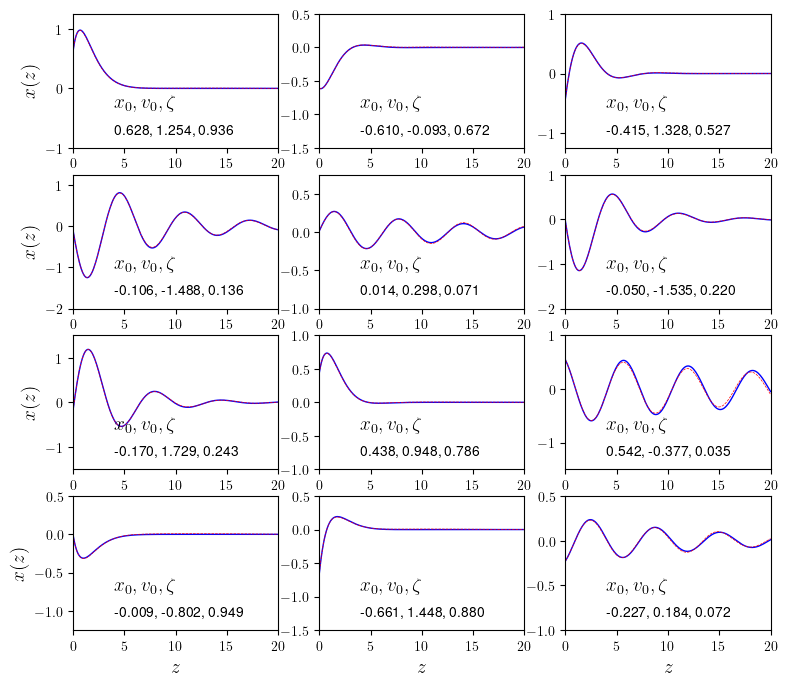

In [26]:
def plot_results(data, 
                 xmin=lower_bounds[0],  xmax=upper_bounds[0],
                 filename='results.png',
                 fgsize=(8, 6), 
                 ftsize=14):

    plt.rcParams.update({'font.size': 10})

    # work out number of columns and number of plots
    ncols = 3
    nrows = len(data) // ncols
    ndata = nrows * ncols

    fgsize= (3*ncols, 2*nrows)
    
    # create an empty figure
    fig = plt.figure(figsize=fgsize)
    fig.tight_layout()

    for i, (z, exact, approx, x0, v0, zeta) in enumerate(data):

        index = i+1
        ax  = fig.add_subplot(nrows, ncols, index)
        
        # setup x-axis
        ax.set_xlim(xmin, xmax)
        
        if i > (nrows-1) * ncols-1:
            ax.set_xlabel(r'$z$', fontsize=ftsize)
        
        if i % ncols == 0:
            ax.set_ylabel(r'$x(z)$', fontsize=ftsize)

        # annotate plot
        dy = 0.25
        ymin = exact.min()
        n = int(np.abs(ymin)/dy)+4
        ymin = np.sign(ymin)*n*dy

        ymax = exact.max()
        n = int(np.abs(ymax)/dy)+2
        ymax = np.sign(ymax)*n*dy
        ax.set_ylim(ymin, ymax)

        xpos = xmin + 0.20 * (xmax-xmin)
        ypos = ymin + 0.30 * (ymax-ymin)
        ystep= (ymax-ymin)/5
        
        ax.text(xpos, ypos, r'$x_0, v_0, \zeta$', fontsize=14); ypos -= ystep
        ax.text(xpos, ypos, '%8.3f,%8.3f,%8.3f' % (x0, v0, zeta))

        ax.plot(z, exact,  color='blue', linestyle='solid', linewidth=1.0)
        ax.plot(z, approx, color='red', linestyle='dashed', linewidth=0.5)
        
    plt.savefig(filename)

plot_results(data)